# A Temporal Analysis of the Performance Stability of Fraud Detection Models Under Concept Drift

#### Research Question: Measure how stable are fraud detction model perfoemnace over time under concept drift, and can retraining strategies reduce performance degradation?
#### Objectives:
1. Measure temporal changes in fraud data.
2. Compare model performance across chronological windows.
3. Evaluate whether retraining improves stability.
4. Identify which model is most robust under drift.
#### Hypothesis: Model performance will degrade over time when data distribution changes, and periodic retraining will reduce this degradation.
#### Evaluation Strategy : Chronological split, drift-focused exploratory analysis, leakage-free preprocessing, and comparison of retraining strategies using PR_AUC and ROC_AUC
#### Key Idea: Use time-ordered evaluation(not random splits)

In [1]:
#!conda install -c conda-forge xgboost -y

In [2]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
#Basic Libraries
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Preprocessing
#To apply different preprocessing steps to different columns in dataset
from sklearn.compose import ColumnTransformer

#Convert dense only when training HistGB
from sklearn.preprocessing import FunctionTransformer

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Paramwter tuning
from sklearn.model_selection import ParameterGrid
from copy import deepcopy

#Metrics
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [4]:
CONFIG = {
    "time_col": "TransactionDT",
    "target_col": "isFraud",
    "id_col": "TransactionID",
    "n_windows": 10,
    "train_upto": 6,
    "max_rows": 500000,
    "neg_to_pos_ratio": 30,
    "random_state": 42
}

## Data Loading and Integration
The IEEE-CIS Fraud Detection dataset contains transaction-level information and identity-related features.  
These two tables are merged using TransactionID to create a single modeling dataset.

In [5]:
#Read datasets
train_trans = pd.read_csv("train_transaction.csv")
train_id = pd.read_csv("train_identity.csv")

print("Transaction shape:", train_trans.shape)
print("Identity shape:", train_id.shape)


Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [6]:
train_trans.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
train_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [8]:
#Merge the datasets (Left merge)
df = train_trans.merge(train_id, on="TransactionID", how="left")
print("Merged shape:", df.shape)

Merged shape: (590540, 434)


## Temporal Ordering
The dataset is sorted by TransactionDT to preserve the real chronological order of transactions.  
This is essential because the study investigates performance stability over time.  
Random shuffling would break the temporal structure and could hide concept drift.

In [9]:
df = df.sort_values(CONFIG["time_col"]).reset_index(drop=True)
df[[CONFIG["time_col"], CONFIG["target_col"]]].head()

,TransactionDT,isFraud
0,86400,0
1,86401,0
2,86469,0
3,86499,0
4,86506,0


## Check Class Imbalance

In [10]:
counts = df[CONFIG["target_col"]].value_counts()
ratios = df[CONFIG["target_col"]].value_counts(normalize=True)

print("Class Counts:\n", counts)
print("\n Class Ratios:\n", ratios)

Class Counts:
 isFraud
0    569877
1     20663
Name: count, dtype: int64

 Class Ratios:
 isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


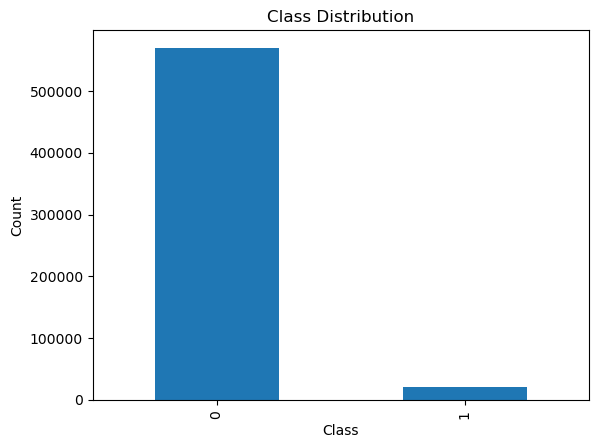

In [11]:
plt.figure()
counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of the total observations.  
Therefore, PR-AUC is used as a primary evaluation metric because it is more informative than accuracy for imbalanced classification problems.  
To avoid temporal leakage, no oversampling technique such as SMOTE is applied before chronological splitting.

## Missing Values

In [12]:
pd.set_option("display.max_rows", None)

missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_pct
})

missing_counts.head(40)

id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_22    585371
id_27    585371
id_23    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_04    524216
id_03    524216
D6       517353
id_33    517251
D8       515614
D9       515614
id_09    515614
id_10    515614
id_30    512975
id_32    512954
id_34    512735
id_14    510496
V162     508595
V163     508595
V147     508595
V149     508595
V139     508595
V154     508595
V153     508595
V148     508595
V155     508595
V157     508595
V158     508595
V142     508595
V141     508595
dtype: int64

A large number of features contain missing values.  
Instead of dropping these columns immediately, missingness is handled during preprocessing using imputation so that temporal information is preserved.

## Check Data Types

In [13]:
pd.set_option('display.max_rows', None)

print(df.dtypes.value_counts())

obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Number of categorical/object columns:", len(obj_cols))
print("Example categorical columns:", obj_cols[:20])

float64    399
object      31
int64        4
Name: count, dtype: int64
Number of categorical/object columns: 31
Example categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28']


#### Data Type Validation
A check was performed to identify whether any apparently categorical columns were actually numeric values stored as text.

In [14]:
#Check if the numeric columns accidently stored as object
suspicious = []
for c in obj_cols:
    sample = df[c].dropna().astype(str).head(200)
    # If most values look like numbers, flag it
    numeric_like = sample.str.match(r"^-?\d+(\.\d+)?$").mean()
    if numeric_like > 0.9:
        suspicious.append(c)

suspicious[:30], len(suspicious)

([], 0)

#### Memory Cleanup
The original transaction and identity tables are deleted after merging to reduce memory usage during later preprocessing and model training stages.

In [15]:
del train_trans
del train_id
gc.collect()

3729

# EDA

## Drift-Focused Exploratory Analysis
To study temporal changes in the dataset, the transactions are divided into 10 chronological windows of approximately equal size.  
These windows are used to observe changes in fraud rate, transaction behaviour, and feature availability over time.

#### Create time bins

In [16]:
#Create time_bins
n_bins = CONFIG["n_windows"]

df = df.copy()
df["time_bin"] = pd.qcut(df[CONFIG["time_col"]], q=n_bins, labels=False, duplicates="drop")
df["time_bin"].value_counts().sort_index()

time_bin
0    59054
1    59054
2    59054
3    59054
4    59054
5    59054
6    59054
7    59054
8    59054
9    59054
Name: count, dtype: int64

Dataset has been split to 10 equal chronological windows.
Each window has 59054 transactions. (Transaction Volume can effect model stability and observed fraud rates)

#### Fraud rate over time

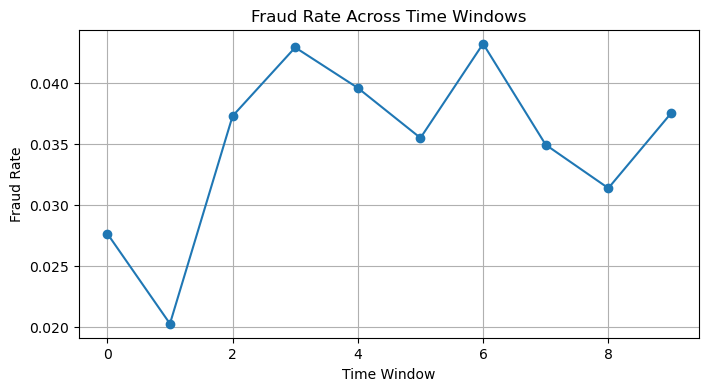

In [17]:
fraud_rate_time = df.groupby("time_bin")[CONFIG["target_col"]].mean()

plt.figure(figsize=(8,4))
fraud_rate_time.plot(marker='o')
plt.title("Fraud Rate Across Time Windows")
plt.xlabel("Time Window")
plt.ylabel("Fraud Rate")
plt.grid(True)
plt.show()

The fraud rate varies across time windows, indicating that the target distribution is not stable over time.  
This suggests the presence of temporal drift and supports the need for time-aware evaluation.

#### Transaction Volume over Time

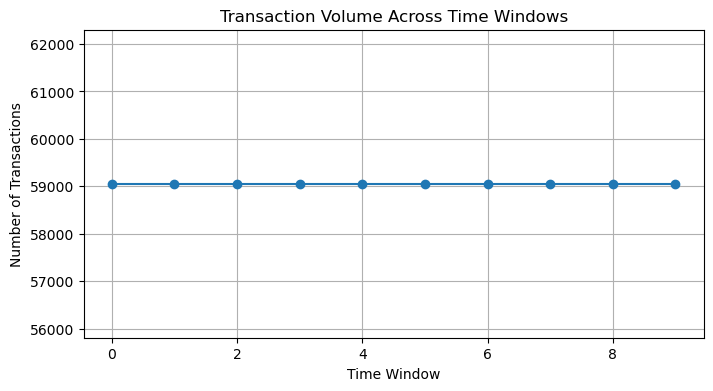

In [18]:
volume_time = df.groupby("time_bin").size()

plt.figure(figsize=(8,4))
volume_time.plot(marker='o')
plt.title("Transaction Volume Across Time Windows")
plt.xlabel("Time Window")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.show()

In [19]:
amount_summary = df.groupby("time_bin")["TransactionAmt"].agg(["mean", "median"])
amount_summary

,mean,median
time_bin,,
0,129.256240,70.000
1,124.192755,78.500
2,135.795109,64.713
3,136.281960,62.950
4,133.587013,59.000
5,146.835681,77.821
6,136.285482,67.950
7,132.976864,67.950
8,138.403914,68.500


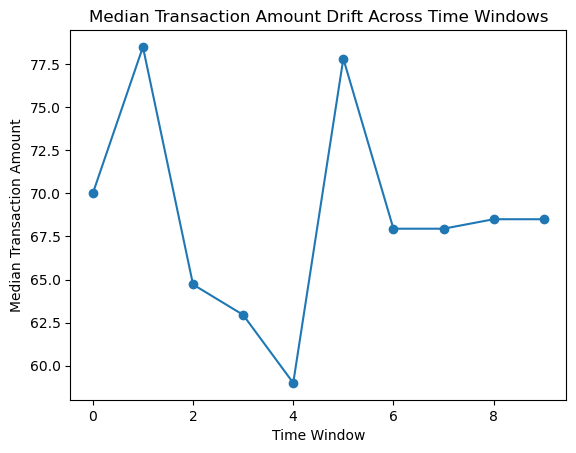

In [20]:
plt.figure()
plt.plot(df.groupby("time_bin")["TransactionAmt"].median(), marker="o")
plt.title("Median Transaction Amount Drift Across Time Windows")
plt.xlabel("Time Window")
plt.ylabel("Median Transaction Amount")
plt.show()

### Feature Drift Example

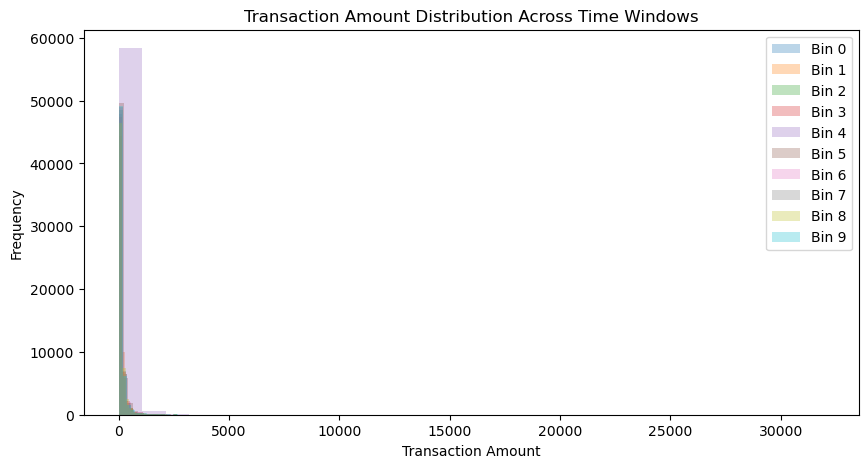

In [21]:
plt.figure(figsize=(10,5))
for b in df["time_bin"].unique():
    subset = df[df["time_bin"] == b]
    plt.hist(subset["TransactionAmt"], bins=30, alpha=0.3, label=f"Bin {b}")

plt.legend()
plt.title("Transaction Amount Distribution Across Time Windows")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

## Fraud vs Non_Fraud Behaviour Drift 

In [22]:
fraud_behaviour = df.groupby(["time_bin", "isFraud"])["TransactionAmt"].median().unstack()

fraud_behaviour

isFraud,0,1
time_bin,,
0,68.950,78.788
1,78.500,80.000
2,64.596,66.696
3,60.000,77.338
4,59.000,64.950
5,77.338,80.000
6,67.950,69.151
7,67.950,77.649
8,68.500,71.563


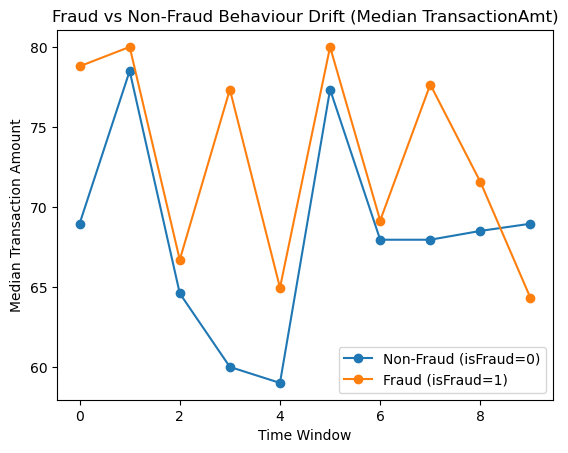

In [23]:
plt.figure()

plt.plot(fraud_behaviour.index, fraud_behaviour[0], marker="o", label="Non-Fraud (isFraud=0)")
plt.plot(fraud_behaviour.index, fraud_behaviour[1], marker="o", label="Fraud (isFraud=1)")

plt.title("Fraud vs Non-Fraud Behaviour Drift (Median TransactionAmt)")
plt.xlabel("Time Window")
plt.ylabel("Median Transaction Amount")
plt.legend()
plt.show()


The separation between fraudulent and non-fraudulent transaction amounts changes across time windows.  
This suggests that the relationship between predictors and the target is evolving over time, which is consistent with concept drift.

### Feature availability 
Identify features that are often missing.

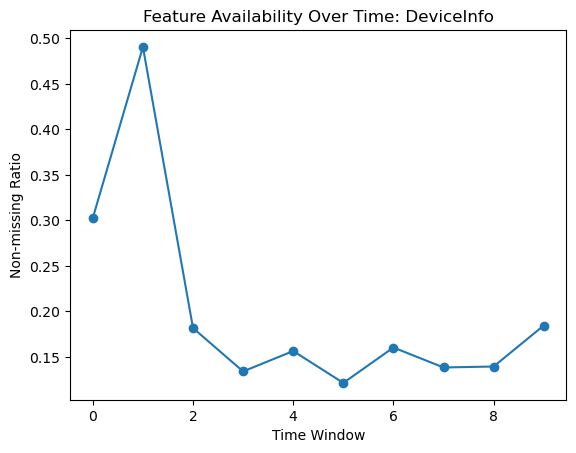

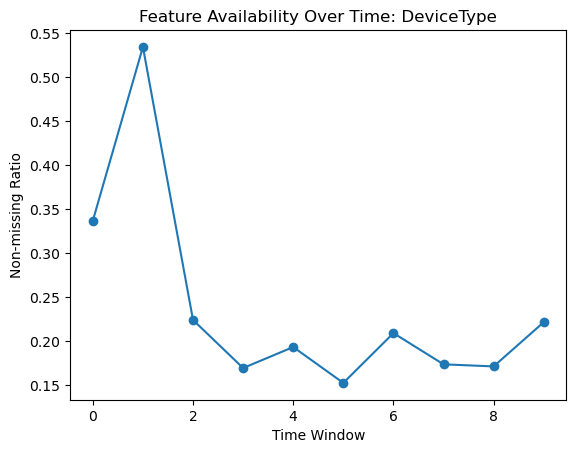

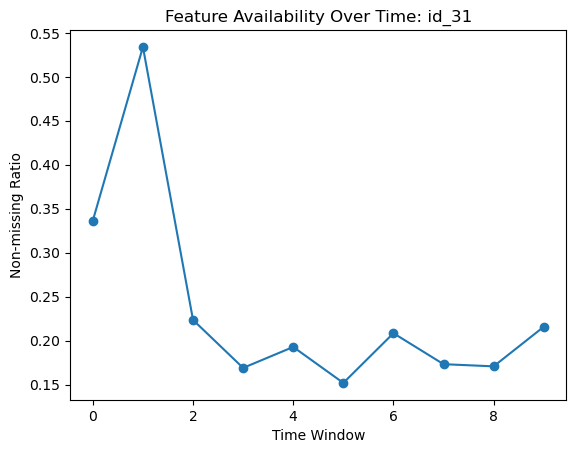

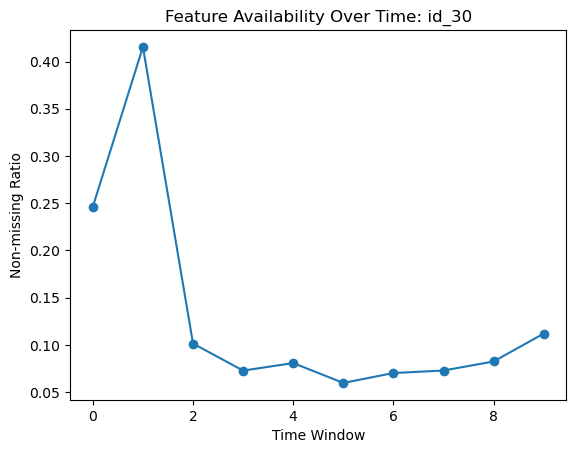

In [25]:
availability_features = ["DeviceInfo", "DeviceType", "id_31", "id_30"]

for feature in availability_features:
    if feature in df.columns:
        availability = df.groupby("time_bin")[feature].apply(lambda x: x.notnull().mean())
        plt.figure()
        plt.plot(availability.index, availability.values, marker="o")
        plt.title(f"Feature Availability Over Time: {feature}")
        plt.xlabel("Time Window")
        plt.ylabel("Non-missing Ratio")
        plt.show()

## Drift quatification

### CSI (Characteristic Stability Index)
CSI gives bumeric measure of how much a feature distribution shifted between time periods.

In addition to visual inspection, drift is measured numerically using stability indices.  
This provides quantitative evidence of distributional change between earlier and later periods.

In [26]:
def calculate_csi(expected, actual, bins=10):
    expected = expected.dropna()
    actual = actual.dropna()

    if len(expected) < 50 or len(actual) < 50:
        return np.nan

    breakpoints = np.linspace(0, 1, bins + 1)
    quantiles = np.quantile(expected, breakpoints)

    quantiles = np.unique(quantiles)
    if len(quantiles) < 3:
        return np.nan

    expected_perc = np.histogram(expected, bins=quantiles)[0] / len(expected)
    actual_perc = np.histogram(actual, bins=quantiles)[0] / len(actual)

    csi = np.sum((actual_perc - expected_perc) * np.log((actual_perc + 1e-6) / (expected_perc + 1e-6)))
    return csi

#### CSI feature selection

In [27]:
exclude_cols = ["TransactionID", "TransactionDT", "isFraud", "time_bin"]

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

missing_ratio = df[numeric_cols].isnull().mean()
filtered_numeric = missing_ratio[missing_ratio < 0.8].index.tolist()

print("Numeric candidates after missingness filter:", len(filtered_numeric))
filtered_numeric[:10]

Numeric candidates after missingness filter: 331


['TransactionAmt',
 'card1',
 'card2',
 'card3',
 'card5',
 'addr1',
 'addr2',
 'dist1',
 'C1',
 'C2']

In [28]:
corr = df[filtered_numeric + ["isFraud"]].corr(numeric_only=True)["isFraud"].abs().sort_values(ascending=False)

top_numeric = corr.head(30).index.tolist()
top_numeric.remove("isFraud")

top_numeric

['V257',
 'V246',
 'V244',
 'V242',
 'V201',
 'V200',
 'V189',
 'V188',
 'V258',
 'V45',
 'V228',
 'V44',
 'V86',
 'V87',
 'V170',
 'V52',
 'V230',
 'V199',
 'V51',
 'V171',
 'V40',
 'V243',
 'V190',
 'V39',
 'V38',
 'V43',
 'V79',
 'V42',
 'V94']

To focus the analysis on relevant variables, CSI is computed for selected numeric features, including TransactionAmt and other variables most strongly associated with the fraud label.

In [29]:
#CSI early vs Late
csi_features = ["TransactionAmt"] + top_numeric if "TransactionAmt" in df.columns else top_numeric

half = len(df)//2
early_df = df.iloc[:half]
late_df = df.iloc[half:]

csi_results = []
for f in csi_features:
    csi_results.append((f, calculate_csi(early_df[f], late_df[f], bins=10)))

csi_df = pd.DataFrame(csi_results, columns=["feature", "CSI"]).sort_values("CSI", ascending=False)
csi_df.head(20)

,feature,CSI
20,V171,0.048987
17,V230,0.031254
11,V228,0.031062
15,V170,0.020963
9,V258,0.015488
21,V40,0.013830
24,V39,0.013723
26,V43,0.013535
28,V42,0.013468
0,TransactionAmt,0.012600


### Calculate PSI

In [30]:
def calculate_psi(expected, actual, bins=10, epsilon=1e-6):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    if len(expected) < 50 or len(actual) < 50:
        return np.nan

    breakpoints = np.linspace(0, 1, bins + 1)
    quantiles = expected.quantile(breakpoints).values
    quantiles = np.unique(quantiles)

    if len(quantiles) < 3:
        return np.nan

    expected_bins = pd.cut(expected, bins=quantiles, include_lowest=True)
    actual_bins = pd.cut(actual, bins=quantiles, include_lowest=True)

    expected_dist = expected_bins.value_counts(normalize=True, sort=False)
    actual_dist = actual_bins.value_counts(normalize=True, sort=False)

    expected_dist = expected_dist.reindex(expected_dist.index, fill_value=epsilon)
    actual_dist = actual_dist.reindex(expected_dist.index, fill_value=epsilon)

    psi = ((actual_dist - expected_dist) * np.log((actual_dist + epsilon) / (expected_dist + epsilon))).sum()
    return psi

In [31]:
# PSI early vs late
psi_features = csi_features.copy()

psi_results = []
for col in psi_features:
    psi_val = calculate_psi(early_df[col], late_df[col], bins=10)
    psi_results.append({"feature": col, "PSI_early_vs_late": psi_val})

psi_df = pd.DataFrame(psi_results).sort_values("PSI_early_vs_late", ascending=False)
psi_df.head(20)

,feature,PSI_early_vs_late
20,V171,0.034626
0,TransactionAmt,0.019915
11,V228,0.014815
17,V230,0.014176
9,V258,0.012842
7,V189,0.009557
5,V201,0.009502
8,V188,0.008110
6,V200,0.007451
15,V170,0.006651


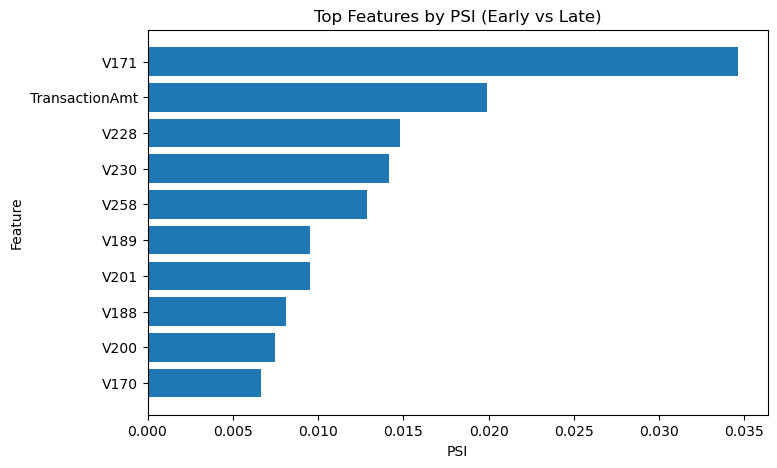

In [32]:
top_psi = psi_df.head(10).sort_values("PSI_early_vs_late")

plt.figure(figsize=(8, 5))
plt.barh(top_psi["feature"], top_psi["PSI_early_vs_late"])
plt.title("Top Features by PSI (Early vs Late)")
plt.xlabel("PSI")
plt.ylabel("Feature")
plt.show()

PSI values are interpreted using standard thresholds:  
PSI < 0.10 indicates minor shift,  
0.10–0.25 indicates moderate shift,  
and PSI > 0.25 indicates significant shift.

## Temporal Window Construction for Modelling
The dataset is divided into ordered windows so that models can be trained on past data and evaluated on future unseen data.

In [33]:
def make_time_windows(df, time_col="TransactionDT", n_windows=10):
    q = np.linspace(0, 1, n_windows + 1)
    cuts = df[time_col].quantile(q).values

    windows = []
    for i in range(n_windows):
        start, end = cuts[i], cuts[i + 1]
        if i == n_windows - 1:
            w = df[(df[time_col] >= start) & (df[time_col] <= end)].copy()
        else:
            w = df[(df[time_col] >= start) & (df[time_col] < end)].copy()
        windows.append(w.reset_index(drop=True))
    return windows

N_WINDOWS = 10
windows = make_time_windows(df, time_col=CONFIG["time_col"], n_windows=N_WINDOWS)
[len(w) for w in windows]

[59054, 59054, 59054, 59054, 59054, 59054, 59054, 59054, 59054, 59054]

## Training Data Reduction
Because the dataset is large and highly imbalanced, training is performed on a reduced sample that retains all fraud cases and a controlled number of non-fraud cases.  
This improves computational efficiency while preserving the minority class signal.

In [34]:
def temporal_train_sample(
    train_df,
    target_col="isFraud",
    max_rows=500000,
    neg_to_pos_ratio=20,
    random_state=42
):

    fraud_df = train_df[train_df[target_col] == 1]
    nonfraud_df = train_df[train_df[target_col] == 0]

    # keep all fraud
    pos_count = len(fraud_df)

    # choose how many non-fraud to keep
    neg_keep = min(len(nonfraud_df), max(pos_count * neg_to_pos_ratio, 10000))
    nonfraud_sample = nonfraud_df.sample(n=neg_keep, random_state=random_state)

    sampled_df = pd.concat([fraud_df, nonfraud_sample], axis=0)

    # hard cap in case dataset is still too large
    if len(sampled_df) > max_rows:
        fraud_df = sampled_df[sampled_df[target_col] == 1]
        nonfraud_df = sampled_df[sampled_df[target_col] == 0]

        remaining = max_rows - len(fraud_df)
        remaining = max(remaining, 0)

        if remaining < len(nonfraud_df):
            nonfraud_df = nonfraud_df.sample(n=remaining, random_state=random_state)

        sampled_df = pd.concat([fraud_df, nonfraud_df], axis=0)

    sampled_df = sampled_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return sampled_df

In [35]:
# print("Training sample shape:", sampled_df.shape)
# print("Fraud ratio in sample:", sampled_df[target_col].mean())

## Preprocessing 

## Leakage-Free Preprocessing
Preprocessing is fitted only on the training data within each temporal split.  
Numeric variables are imputed using the median, while categorical variables are imputed using the most frequent category and then one-hot encoded.  
Time-related variables such as TransactionDT and time_bin are excluded from the predictors to prevent temporal leakage.

In [36]:
def build_preprocessor(X_train, time_col="TransactionDT"):
    # remove time variables from prediction features
    drop_cols = [time_col, "time_bin"]
    feature_cols = [c for c in X_train.columns if c not in drop_cols]

    X_use = X_train[feature_cols]

    cat_cols = X_use.select_dtypes(include=["object"]).columns.tolist()
    num_cols = [c for c in feature_cols if c not in cat_cols]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ], remainder="drop")

    return preprocessor, feature_cols

## Model Selection
Three models are used for comparison:
- Logistic Regression as a simple and interpretable baseline,
- Random Forest as a non-linear ensemble model,
- XGBoost as a strong gradient boosting model for tabular fraud detection.

In [37]:
#dataset is very imbalanced. scale_pos_weight helps XGBoost focus more on fraud cases.

In [38]:
def get_models(df_train, best_params=None):
    y = df_train["isFraud"].astype(int)
    pos = (y == 1).sum()
    neg = (y == 0).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1

    best_params = best_params or {}

    return {
        "LogReg": LogisticRegression(
            max_iter=300,
            class_weight="balanced",
            solver="saga",
            random_state=42,
            **best_params.get("LogReg", {})
        ),
        "RandomForest": RandomForestClassifier(
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=42,
            **best_params.get("RandomForest", {})
        ),
        "XGBoost": XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
            **best_params.get("XGBoost", {})
        )
    }

## Evaluation Methods

In [39]:
#Function to predict scores
def predict_scores(pipe, X):
    model = pipe.named_steps["model"]
    if hasattr(model, "predict_proba"):
        return pipe.predict_proba(X)[:, 1]
    return pipe.decision_function(X)

In [40]:
def compute_metrics(y_true, scores, threshold=0.5):
    preds = (scores >= threshold).astype(int)

    return {
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0)
    }

In [41]:
def stability_summary(scores_df, metric="pr_auc"):
    rows = []
    for (strategy, model), g in scores_df.groupby(["strategy", "model"]):
        g = g.sort_values("test_window")
        first = g.iloc[0][metric]
        last = g.iloc[-1][metric]
        rows.append({
            "strategy": strategy,
            "model": model,
            f"{metric}_mean": g[metric].mean(),
            f"{metric}_std": g[metric].std(),
            f"{metric}_degradation": first - last,
            f"{metric}_min": g[metric].min(),
            "windows_tested": len(g)
        })
    return pd.DataFrame(rows).sort_values([f"{metric}_mean", f"{metric}_std"], ascending=[False, True])


In [42]:
def plot_metric_over_time(scores_df, metric="pr_auc"):
    plt.figure()
    for (strategy, model), g in scores_df.groupby(["strategy", "model"]):
        g = g.sort_values("test_window")
        plt.plot(g["test_window"], g[metric], marker="o", label=f"{strategy}-{model}")
    plt.title(f"{metric.upper()} over time windows")
    plt.xlabel("Test window")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.tight_layout()
    plt.show()

## Parameter Tuning
Hyperparameters are tuned using only the initial training period in order to avoid temporal leakage.  
The tuned parameters are then used in all later evaluation strategies.

In [43]:
#Parameter Grids
param_grids = {
    "LogReg": {
        "C": [0.1, 1, 5]
    },
    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [8, 12],
        "min_samples_split": [10, 20],
        "min_samples_leaf": [5, 10]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [4, 6],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8],
        "colsample_bytree": [0.8]
    }
}

### Best parameters for models

In [44]:
def tune_models_temporally(windows, config, param_grids):

    target_col = config["target_col"]
    train_upto = config["train_upto"]
    max_rows = config["max_rows"]
    neg_to_pos_ratio = config["neg_to_pos_ratio"]
    random_state = config["random_state"]

    # Use early windows for tuning only
    tune_train_df = pd.concat(windows[:train_upto-1], axis=0)
    tune_valid_df = windows[train_upto-1]

    tune_train_df = temporal_train_sample(tune_train_df, 
        target_col=target_col,
        max_rows=max_rows,
        neg_to_pos_ratio=neg_to_pos_ratio,
        random_state=random_state
        )

    y_train = tune_train_df["isFraud"].astype(int).values
    X_train = tune_train_df.drop(columns=["isFraud"], errors="ignore")

    y_valid = tune_valid_df["isFraud"].astype(int).values
    X_valid = tune_valid_df.drop(columns=["isFraud"], errors="ignore")

    preprocessor, feature_cols = build_preprocessor(X_train)

    base_models = get_models(tune_train_df, best_params=None)
    best_params = {}

    for model_name, base_model in base_models.items():
        print(f"Tuning {model_name}...")
        best_score = -1
        best_param = None

        for params in ParameterGrid(param_grids[model_name]):
            model = deepcopy(base_model)
            model.set_params(**params)

            pipe = Pipeline([
                ("prep", preprocessor),
                ("model", model)
            ])

            pipe.fit(X_train[feature_cols], y_train)
            scores = predict_scores(pipe, X_valid[feature_cols])
            pr_auc = average_precision_score(y_valid, scores)

            if pr_auc > best_score:
                best_score = pr_auc
                best_param = params

        best_params[model_name] = best_param
        print(f"Best params for {model_name}: {best_param}, PR-AUC={best_score:.4f}")

    return best_params

In [45]:
best_params = tune_models_temporally(windows, CONFIG, param_grids)

best_params

Tuning LogReg...
Best params for LogReg: {'C': 0.1}, PR-AUC=0.0865
Tuning RandomForest...
Best params for RandomForest: {'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 200}, PR-AUC=0.4127
Tuning XGBoost...
Best params for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}, PR-AUC=0.4801


{'LogReg': {'C': 0.1},
 'RandomForest': {'max_depth': 12,
  'min_samples_leaf': 10,
  'min_samples_split': 10,
  'n_estimators': 200},
 'XGBoost': {'colsample_bytree': 0.8,
  'learning_rate': 0.1,
  'max_depth': 6,
  'n_estimators': 200,
  'subsample': 0.8}}

## Model retraining experiments

## Strategy 1: No Retraining Baseline
Models are trained on the initial set of windows and then evaluated on future windows without updating.  
This simulates a static deployment setting and allows direct observation of performance degradation over time.

In [46]:
def eval_no_retrain(windows, config, best_params):

    target_col = config["target_col"]
    train_upto = config["train_upto"]
    max_rows = config["max_rows"]
    neg_to_pos_ratio = config["neg_to_pos_ratio"]
    random_state = config["random_state"]
    
    train_df = pd.concat(windows[:train_upto], axis=0)

    # reduce only training data
    train_df = temporal_train_sample(
        train_df,
        target_col=target_col,
        max_rows=max_rows,
        neg_to_pos_ratio=neg_to_pos_ratio,
        random_state=random_state
    )

    print("Training smaple size:", len(train_df))
    print("Fraud ratio in sampled training set:", train_df[target_col].mean())

    y_train = train_df[target_col].astype(int).values
    X_train = train_df.drop(columns=[target_col], errors="ignore")

    preprocessor, feature_cols = build_preprocessor(X_train)

    results = []
    models = get_models(train_df, best_params=best_params)

    for model_name, model in models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        pipe.fit(X_train[feature_cols], y_train)

        for i, w in enumerate(windows[train_upto:], start=train_upto + 1):
            y_test = w["isFraud"].astype(int).values
            X_test = w.drop(columns=["isFraud"], errors="ignore")

            scores = predict_scores(pipe, X_test[feature_cols])

            results.append({
                "strategy": "no_retrain",
                "model": model_name,
                "test_window": i,
                "roc_auc": roc_auc_score(y_test, scores),
                "pr_auc": average_precision_score(y_test, scores)
            })

    return pd.DataFrame(results)


TRAIN_UPTO = 6
baseline_scores = eval_no_retrain(
    windows,
    config=CONFIG,
    best_params=best_params
)
baseline_scores

Training smaple size: 354324
Fraud ratio in sampled training set: 0.03383344057980831


,strategy,model,test_window,roc_auc,pr_auc
0,no_retrain,LogReg,7,0.729902,0.117747
1,no_retrain,LogReg,8,0.715751,0.102754
2,no_retrain,LogReg,9,0.682889,0.071986
3,no_retrain,LogReg,10,0.695954,0.073726
4,no_retrain,RandomForest,7,0.885938,0.515427
5,no_retrain,RandomForest,8,0.874084,0.452057
6,no_retrain,RandomForest,9,0.843852,0.382838
7,no_retrain,RandomForest,10,0.868127,0.460570
8,no_retrain,XGBoost,7,0.922526,0.597064
9,no_retrain,XGBoost,8,0.913300,0.534402


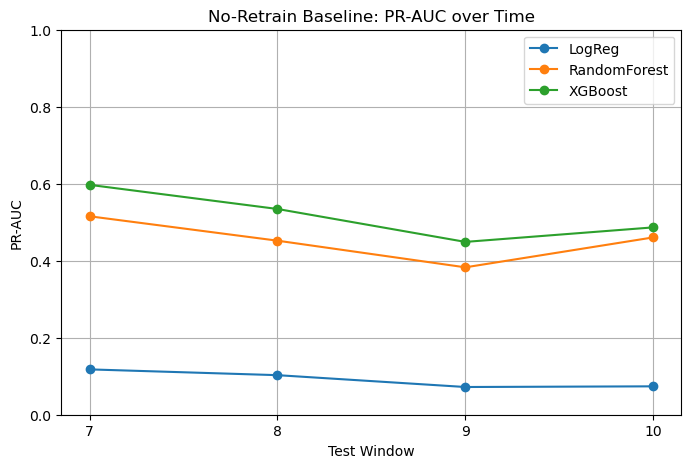

In [47]:
# Sort by test_window
g = baseline_scores.sort_values("test_window")

plt.figure(figsize=(8, 5))
for model_name in g["model"].unique():
    model_data = g[g["model"] == model_name]
    plt.plot(
        model_data["test_window"], 
        model_data["pr_auc"], 
        marker="o", 
        label=model_name
    )

plt.title("No-Retrain Baseline: PR-AUC over Time")
plt.xlabel("Test Window")
plt.ylabel("PR-AUC")
plt.xticks(model_data["test_window"])
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

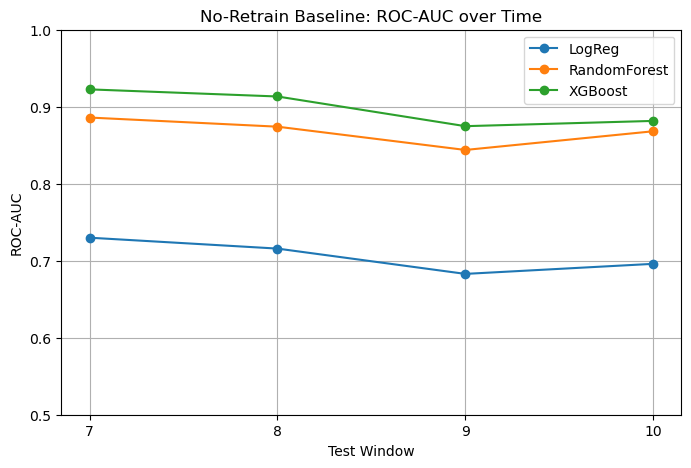

In [48]:
plt.figure(figsize=(8,5))
for model_name in g["model"].unique():
    model_data = g[g["model"] == model_name]
    plt.plot(
        model_data["test_window"], 
        model_data["roc_auc"], 
        marker="o", 
        label=model_name
    )

plt.title("No-Retrain Baseline: ROC-AUC over Time")
plt.xlabel("Test Window")
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 1.0)  # ROC-AUC random baseline is 0.5
plt.xticks(model_data["test_window"])
plt.grid(True)
plt.legend()
plt.show()

## Strategy 2: Fixed Retraining

In [49]:
def eval_fixed_retrain(windows, retrain_every, config, best_params):
    results = []

    target_col = config["target_col"]
    train_upto = config["train_upto"]
    max_rows = config["max_rows"]
    neg_to_pos_ratio = config["neg_to_pos_ratio"]
    random_state = config["random_state"]
    
    # initial sampled training set for model setup
    train_df0 = pd.concat(windows[:train_upto], axis=0)
    train_df0 = temporal_train_sample(
        train_df0,
        target_col=target_col,
        max_rows=max_rows,
        neg_to_pos_ratio=neg_to_pos_ratio,
        random_state=random_state
    )

    print("Training smaple size:", len(train_df0))
    print("Fraud ratio in sampled training set:", train_df0[target_col].mean())

    models = get_models(train_df0, best_params=best_params)

    for model_name, model in models.items():
        pipe = None
        feature_cols = None

        for test_idx in range(train_upto, len(windows)):

            # retrain at first test window and then every N windows
            if (test_idx == train_upto) or ((test_idx - train_upto) % retrain_every == 0):
                train_df = pd.concat(windows[:test_idx], axis=0)

                # reduce only training data
                train_df = temporal_train_sample(
                    train_df,
                    target_col=target_col,
                    max_rows=max_rows,
                    neg_to_pos_ratio=neg_to_pos_ratio,
                    random_state=random_state + test_idx
                )

                y_train = train_df[target_col].astype(int).values
                X_train = train_df.drop(columns=[target_col], errors="ignore")

                preprocessor, feature_cols = build_preprocessor(X_train)
                pipe = Pipeline([("prep", preprocessor), ("model", model)])
                pipe.fit(X_train[feature_cols], y_train)

            # test on full current window
            w = windows[test_idx]
            y_test = w["isFraud"].astype(int).values
            X_test = w.drop(columns=["isFraud"], errors="ignore")

            scores = predict_scores(pipe, X_test[feature_cols])

            results.append({
                "strategy": f"fixed_{retrain_every}",
                "model": model_name,
                "test_window": test_idx,
                "roc_auc": roc_auc_score(y_test, scores),
                "pr_auc": average_precision_score(y_test, scores)
            })

    return pd.DataFrame(results)


### Retraining every time window

In [50]:
fixed_scores_1 = eval_fixed_retrain(windows, retrain_every=1, config=CONFIG, best_params=best_params)

fixed_scores_1

Training smaple size: 354324
Fraud ratio in sampled training set: 0.03383344057980831


,strategy,model,test_window,roc_auc,pr_auc
0,fixed_1,LogReg,6,0.742052,0.123184
1,fixed_1,LogReg,7,0.733900,0.114499
2,fixed_1,LogReg,8,0.722803,0.083607
3,fixed_1,LogReg,9,0.744248,0.086417
4,fixed_1,RandomForest,6,0.886200,0.515100
5,fixed_1,RandomForest,7,0.877347,0.466463
6,fixed_1,RandomForest,8,0.851821,0.398116
7,fixed_1,RandomForest,9,0.883795,0.484877
8,fixed_1,XGBoost,6,0.922908,0.585088
9,fixed_1,XGBoost,7,0.920333,0.578668


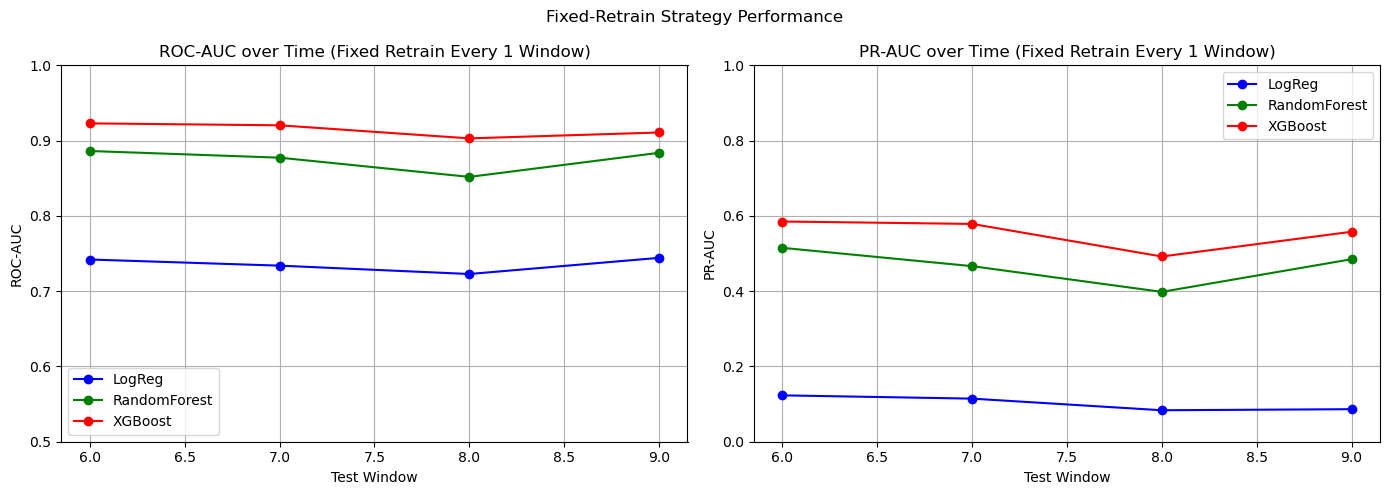

In [51]:
# Sort by test_window
fixed_scores_1 = fixed_scores_1.sort_values("test_window")

# Set up colors for models
colors = {"LogReg": "blue", "RandomForest": "green", "XGBoost": "red"}

# Create figure with 2 subplots: ROC-AUC and PR-AUC
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True)

# Plot ROC-AUC
for model_name in fixed_scores_1["model"].unique():
    model_data = fixed_scores_1[fixed_scores_1["model"] == model_name]
    axes[0].plot(
        model_data["test_window"], 
        model_data["roc_auc"], 
        marker="o", 
        label=model_name,
        color=colors[model_name]
    )
axes[0].set_title("ROC-AUC over Time (Fixed Retrain Every 1 Window)")
axes[0].set_xlabel("Test Window")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(True)
axes[0].legend()

# Plot PR-AUC
for model_name in fixed_scores_1["model"].unique():
    model_data = fixed_scores_1[fixed_scores_1["model"] == model_name]
    axes[1].plot(
        model_data["test_window"], 
        model_data["pr_auc"], 
        marker="o", 
        label=model_name,
        color=colors[model_name]
    )
axes[1].set_title("PR-AUC over Time (Fixed Retrain Every 1 Window)")
axes[1].set_xlabel("Test Window")
axes[1].set_ylabel("PR-AUC")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Fixed-Retrain Strategy Performance")
plt.tight_layout()
plt.show()

### Retraining every 2 time windows

In [52]:
fixed_scores_2 = eval_fixed_retrain(windows, retrain_every=2, config=CONFIG, best_params=best_params)

fixed_scores_2

Training smaple size: 354324
Fraud ratio in sampled training set: 0.03383344057980831


,strategy,model,test_window,roc_auc,pr_auc
0,fixed_2,LogReg,6,0.742052,0.123184
1,fixed_2,LogReg,7,0.728328,0.111833
2,fixed_2,LogReg,8,0.722803,0.083607
3,fixed_2,LogReg,9,0.733876,0.081444
4,fixed_2,RandomForest,6,0.886200,0.515100
5,fixed_2,RandomForest,7,0.874406,0.454333
6,fixed_2,RandomForest,8,0.851821,0.398116
7,fixed_2,RandomForest,9,0.876413,0.470663
8,fixed_2,XGBoost,6,0.922908,0.585088
9,fixed_2,XGBoost,7,0.908320,0.528507


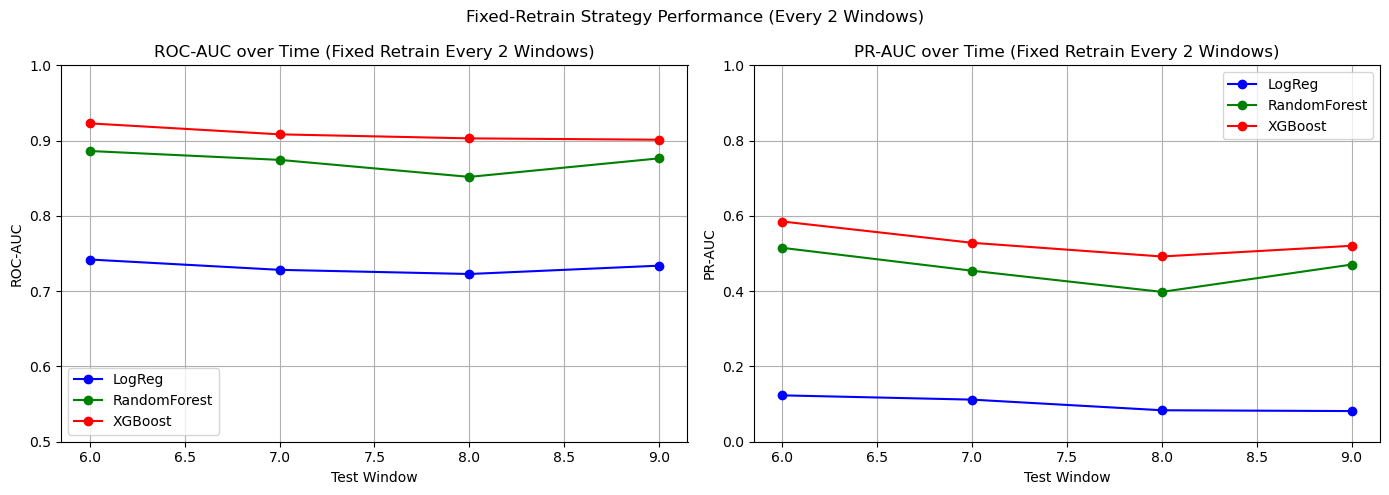

In [53]:
# Sort by test_window
fixed_scores_2 = fixed_scores_2.sort_values("test_window")


colors = {"LogReg": "blue", "RandomForest": "green", "XGBoost": "red"}

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True)

# Plot ROC-AUC
for model_name in fixed_scores_2["model"].unique():
    model_data = fixed_scores_2[fixed_scores_2["model"] == model_name]
    axes[0].plot(
        model_data["test_window"], 
        model_data["roc_auc"], 
        marker="o", 
        label=model_name,
        color=colors[model_name]
    )
axes[0].set_title("ROC-AUC over Time (Fixed Retrain Every 2 Windows)")
axes[0].set_xlabel("Test Window")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(True)
axes[0].legend()

# Plot PR-AUC
for model_name in fixed_scores_2["model"].unique():
    model_data = fixed_scores_2[fixed_scores_2["model"] == model_name]
    axes[1].plot(
        model_data["test_window"], 
        model_data["pr_auc"], 
        marker="o", 
        label=model_name,
        color=colors[model_name]
    )
axes[1].set_title("PR-AUC over Time (Fixed Retrain Every 2 Windows)")
axes[1].set_xlabel("Test Window")
axes[1].set_ylabel("PR-AUC")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Fixed-Retrain Strategy Performance (Every 2 Windows)")
plt.tight_layout()
plt.show()

### Retraining every 3 time windows 

In [54]:
fixed_scores_3 = eval_fixed_retrain(windows, retrain_every=3, config=CONFIG, best_params=best_params)

fixed_scores_3

Training smaple size: 354324
Fraud ratio in sampled training set: 0.03383344057980831


,strategy,model,test_window,roc_auc,pr_auc
0,fixed_3,LogReg,6,0.742052,0.123184
1,fixed_3,LogReg,7,0.728328,0.111833
2,fixed_3,LogReg,8,0.698015,0.075692
3,fixed_3,LogReg,9,0.744248,0.086417
4,fixed_3,RandomForest,6,0.886200,0.515100
5,fixed_3,RandomForest,7,0.874406,0.454333
6,fixed_3,RandomForest,8,0.843104,0.382827
7,fixed_3,RandomForest,9,0.883795,0.484877
8,fixed_3,XGBoost,6,0.922908,0.585088
9,fixed_3,XGBoost,7,0.908320,0.528507


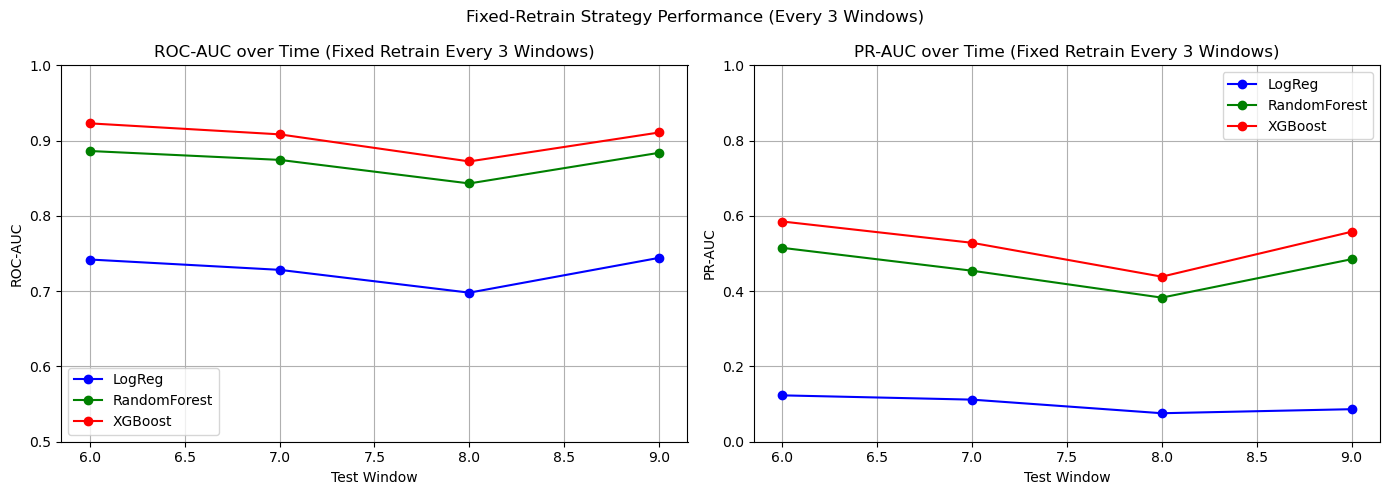

In [55]:
# Sort by test_window
fixed_scores_3 = fixed_scores_3.sort_values("test_window")

colors = {"LogReg": "blue", "RandomForest": "green", "XGBoost": "red"}

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True)

# Plot ROC-AUC
for model_name in fixed_scores_3["model"].unique():
    model_data = fixed_scores_3[fixed_scores_3["model"] == model_name]
    axes[0].plot(
        model_data["test_window"], 
        model_data["roc_auc"], 
        marker="o", 
        label=model_name,
        color=colors[model_name]
    )
axes[0].set_title("ROC-AUC over Time (Fixed Retrain Every 3 Windows)")
axes[0].set_xlabel("Test Window")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(True)
axes[0].legend()

# Plot PR-AUC
for model_name in fixed_scores_3["model"].unique():
    model_data = fixed_scores_3[fixed_scores_3["model"] == model_name]
    axes[1].plot(
        model_data["test_window"], 
        model_data["pr_auc"], 
        marker="o", 
        label=model_name,
        color=colors[model_name]
    )
axes[1].set_title("PR-AUC over Time (Fixed Retrain Every 3 Windows)")
axes[1].set_xlabel("Test Window")
axes[1].set_ylabel("PR-AUC")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Fixed-Retrain Strategy Performance (Every 3 Windows)")
plt.tight_layout()
plt.show()

## Strategy 3: Performance-Triggered Retraining

In this strategy, retraining is performed adaptively based on model performance rather than at fixed time intervals.  
A model is retrained only when the selected evaluation metric shows a sustained relative decline compared with a reference performance level.

Unlike the earlier fixed-threshold design, this updated approach uses:

- **relative performance degradation** instead of a fixed absolute drop
- **persistence condition** to avoid retraining due to short-term fluctuations
- **multiple trigger thresholds** to evaluate sensitivity

Specifically, the model is retrained when the PR-AUC falls below a defined percentage of the reference score for **two consecutive time windows**.  
To avoid selecting a threshold arbitrarily, three degradation levels were evaluated: **5%, 10%, and 15%**.

This strategy better reflects a realistic adaptive maintenance setting, where retraining is triggered only when performance deterioration is sufficiently meaningful and persistent.

In [56]:
def eval_performance_trigger_retrain(
    windows,
    config,
    best_params,
    metric_name="pr_auc",
    relative_drop=0.10,    
    patience=2               
):
    target_col = config["target_col"]
    train_upto = config["train_upto"]
    max_rows = config["max_rows"]
    neg_to_pos_ratio = config["neg_to_pos_ratio"]
    random_state = config["random_state"]

    results = []

    # initial sampled training data for model setup
    train_df = pd.concat(windows[:train_upto], axis=0)
    train_df = temporal_train_sample(
        train_df,
        target_col=target_col,
        max_rows=max_rows,
        neg_to_pos_ratio=neg_to_pos_ratio,
        random_state=random_state
    )

    print("Training sample size:", len(train_df))
    print("Fraud ratio in sampled training set:", train_df[target_col].mean())

    models = get_models(train_df, best_params=best_params)

    for model_name, model in models.items():
        current_train_end = train_upto
        bad_count = 0

       
        current_train_df = pd.concat(windows[:current_train_end], axis=0)
        current_train_df = temporal_train_sample(
            current_train_df,
            target_col=target_col,
            max_rows=max_rows,
            neg_to_pos_ratio=neg_to_pos_ratio,
            random_state=random_state
        )

        y_train = current_train_df[target_col].astype(int).values
        X_train = current_train_df.drop(columns=[target_col], errors="ignore")

        preprocessor, feature_cols = build_preprocessor(X_train)
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        pipe.fit(X_train[feature_cols], y_train)

        reference_score = None

        for test_idx in range(train_upto, len(windows)):
            w = windows[test_idx]

            y_test = w[target_col].astype(int).values
            X_test = w.drop(columns=[target_col], errors="ignore")

            scores = predict_scores(pipe, X_test[feature_cols])

            roc_auc = roc_auc_score(y_test, scores)
            pr_auc = average_precision_score(y_test, scores)

            current_metric = pr_auc if metric_name == "pr_auc" else roc_auc

            retrained = False
            threshold_score = None
            degradation_ratio = None

            # first observed performance becomes baseline reference
            if reference_score is None:
                reference_score = current_metric
                threshold_score = reference_score * (1 - relative_drop)
                degradation_ratio = 0.0
            else:
                threshold_score = reference_score * (1 - relative_drop)

                if reference_score > 0:
                    degradation_ratio = (reference_score - current_metric) / reference_score
                else:
                    degradation_ratio = 0.0

                # check whether current window is below trigger threshold
                if current_metric < threshold_score:
                    bad_count += 1
                else:
                    bad_count = 0

                # retrain only if drop persists for patience windows
                if bad_count >= patience:
                    current_train_end = test_idx

                    retrain_df = pd.concat(windows[:current_train_end], axis=0)
                    retrain_df = temporal_train_sample(
                        retrain_df,
                        target_col=target_col,
                        max_rows=max_rows,
                        neg_to_pos_ratio=neg_to_pos_ratio,
                        random_state=random_state + test_idx
                    )

                    y_train = retrain_df[target_col].astype(int).values
                    X_train = retrain_df.drop(columns=[target_col], errors="ignore")

                    preprocessor, feature_cols = build_preprocessor(X_train)
                    pipe = Pipeline([("prep", preprocessor), ("model", model)])
                    pipe.fit(X_train[feature_cols], y_train)

                    retrained = True
                    bad_count = 0

                    # keep the current window score recorded 
                    # update reference from the most recent observed score
                    reference_score = current_metric

            results.append({
                "strategy": f"perf_trigger_{metric_name}_rel{relative_drop}_p{patience}",
                "model": model_name,
                "test_window": test_idx,
                "roc_auc": roc_auc,
                "pr_auc": pr_auc,
                "trigger_metric": current_metric,
                "reference_score": reference_score,
                "threshold_score": threshold_score,
                "degradation_ratio": degradation_ratio,
                "bad_count": bad_count,
                "retrained": retrained
            })

    return pd.DataFrame(results)

### Threshold Sensitivity Analysis for Adaptive Retraining

To justify the trigger setting, the adaptive retraining strategy was evaluated using three relative degradation thresholds: **5%, 10%, and 15%**.

These thresholds were selected to compare different levels of sensitivity:

- **5% threshold**: highly sensitive and likely to retrain more frequently
- **10% threshold**: moderate sensitivity, expected to balance responsiveness and stability
- **15% threshold**: less sensitive and more conservative, likely to retrain less often

A persistence rule of **two consecutive degraded windows** was also applied to reduce the risk of retraining in response to random short-term variation.

The purpose of this analysis is to determine which threshold provides the best trade-off between:

- maintaining predictive performance
- reducing unnecessary retraining
- improving temporal stability under concept drift

In [57]:
trigger_results = []

for rel_drop in [0.05, 0.10, 0.15]:
    temp_scores = eval_performance_trigger_retrain(
        windows,
        config=CONFIG,
        best_params=best_params,
        metric_name="pr_auc",
        relative_drop=rel_drop,
        patience=2
    )
    trigger_results.append(temp_scores)

perf_scores_all = pd.concat(trigger_results, axis=0).reset_index(drop=True)

perf_scores_all.head()

Training sample size: 354324
Fraud ratio in sampled training set: 0.03383344057980831
Training sample size: 354324
Fraud ratio in sampled training set: 0.03383344057980831
Training sample size: 354324
Fraud ratio in sampled training set: 0.03383344057980831


,strategy,model,test_window,roc_auc,pr_auc,trigger_metric,reference_score,threshold_score,degradation_ratio,bad_count,retrained
0,perf_trigger_pr_auc_rel0.05_p2,LogReg,6,0.729902,0.117747,0.117747,0.117747,0.111860,0.000000,0,False
1,perf_trigger_pr_auc_rel0.05_p2,LogReg,7,0.715751,0.102754,0.102754,0.117747,0.111860,0.127335,1,False
2,perf_trigger_pr_auc_rel0.05_p2,LogReg,8,0.682889,0.071986,0.071986,0.071986,0.111860,0.388642,0,True
3,perf_trigger_pr_auc_rel0.05_p2,LogReg,9,0.733876,0.081444,0.081444,0.071986,0.068386,-0.131396,0,False
4,perf_trigger_pr_auc_rel0.05_p2,RandomForest,6,0.885938,0.515427,0.515427,0.515427,0.489656,0.000000,0,False


### Summary of Adaptive Retraining Results

The table below compares the adaptive retraining strategies across the tested degradation thresholds.  
For each model and threshold setting, the following are reported:

- mean ROC-AUC
- mean PR-AUC
- standard deviation of PR-AUC
- number of retraining events

This comparison helps identify the threshold that offers the most suitable balance between temporal performance stability and retraining frequency.

In [58]:
adaptive_summary = (
    perf_scores_all
    .groupby(["strategy", "model"], as_index=False)
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
        std_pr_auc=("pr_auc", "std"),
        retrain_count=("retrained", "sum")
    )
    .sort_values(["model", "mean_pr_auc"], ascending=[True, False])
)

adaptive_summary

,strategy,model,mean_roc_auc,mean_pr_auc,std_pr_auc,retrain_count
0,perf_trigger_pr_auc_rel0.05_p2,LogReg,0.715604,0.093483,0.020670,1
6,perf_trigger_pr_auc_rel0.1_p2,LogReg,0.715604,0.093483,0.020670,1
3,perf_trigger_pr_auc_rel0.15_p2,LogReg,0.706124,0.091553,0.022452,1
1,perf_trigger_pr_auc_rel0.05_p2,RandomForest,0.870072,0.455246,0.055114,1
7,perf_trigger_pr_auc_rel0.1_p2,RandomForest,0.870072,0.455246,0.055114,1
4,perf_trigger_pr_auc_rel0.15_p2,RandomForest,0.868000,0.452723,0.054399,0
2,perf_trigger_pr_auc_rel0.05_p2,XGBoost,0.902935,0.525224,0.060809,1
8,perf_trigger_pr_auc_rel0.1_p2,XGBoost,0.902935,0.525224,0.060809,1
5,perf_trigger_pr_auc_rel0.15_p2,XGBoost,0.898036,0.516738,0.063968,1


### Selection of the Final Adaptive Threshold

After comparing the adaptive retraining strategies across multiple degradation thresholds, one threshold is selected for inclusion in the final comparative analysis with the baseline and fixed retraining strategies.

This selection should be based on the overall balance between:

- mean PR-AUC
- temporal stability
- retraining frequency

The chosen threshold is then used as the representative adaptive retraining strategy in the combined results section.

In [59]:
perf_scores = perf_scores_all[
    perf_scores_all["strategy"] == "perf_trigger_pr_auc_rel0.1_p2"
].copy()

perf_scores

,strategy,model,test_window,roc_auc,pr_auc,trigger_metric,reference_score,threshold_score,degradation_ratio,bad_count,retrained
12,perf_trigger_pr_auc_rel0.1_p2,LogReg,6,0.729902,0.117747,0.117747,0.117747,0.105973,0.000000,0,False
13,perf_trigger_pr_auc_rel0.1_p2,LogReg,7,0.715751,0.102754,0.102754,0.117747,0.105973,0.127335,1,False
14,perf_trigger_pr_auc_rel0.1_p2,LogReg,8,0.682889,0.071986,0.071986,0.071986,0.105973,0.388642,0,True
15,perf_trigger_pr_auc_rel0.1_p2,LogReg,9,0.733876,0.081444,0.081444,0.071986,0.064787,-0.131396,0,False
16,perf_trigger_pr_auc_rel0.1_p2,RandomForest,6,0.885938,0.515427,0.515427,0.515427,0.463885,0.000000,0,False
17,perf_trigger_pr_auc_rel0.1_p2,RandomForest,7,0.874084,0.452057,0.452057,0.515427,0.463885,0.122948,1,False
18,perf_trigger_pr_auc_rel0.1_p2,RandomForest,8,0.843852,0.382838,0.382838,0.382838,0.463885,0.257242,0,True
19,perf_trigger_pr_auc_rel0.1_p2,RandomForest,9,0.876413,0.470663,0.470663,0.382838,0.344554,-0.229405,0,False
20,perf_trigger_pr_auc_rel0.1_p2,XGBoost,6,0.922526,0.597064,0.597064,0.597064,0.537358,0.000000,0,False
21,perf_trigger_pr_auc_rel0.1_p2,XGBoost,7,0.913300,0.534402,0.534402,0.597064,0.537358,0.104951,1,False


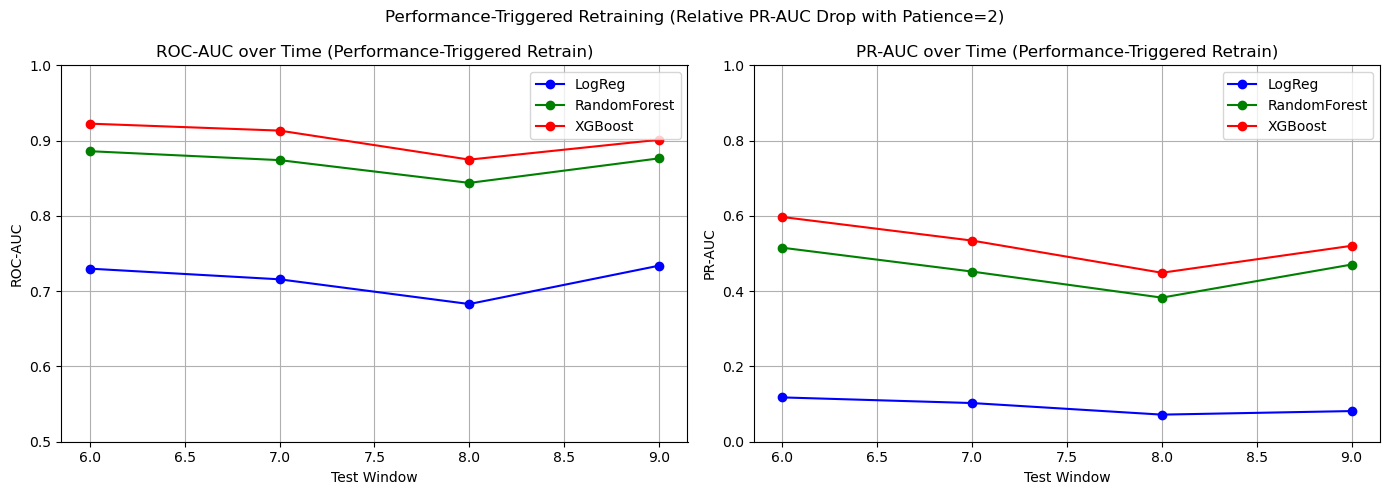

In [60]:
# Sort by test_window
perf_scores = perf_scores.sort_values("test_window")

colors = {"LogReg": "blue", "RandomForest": "green", "XGBoost": "red"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for model_name in perf_scores["model"].unique():
    model_data = perf_scores[perf_scores["model"] == model_name]
    axes[0].plot(
        model_data["test_window"],
        model_data["roc_auc"],
        marker="o",
        label=model_name,
        color=colors[model_name]
    )

axes[0].set_title("ROC-AUC over Time (Performance-Triggered Retrain)")
axes[0].set_xlabel("Test Window")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(True)
axes[0].legend()

for model_name in perf_scores["model"].unique():
    model_data = perf_scores[perf_scores["model"] == model_name]
    axes[1].plot(
        model_data["test_window"],
        model_data["pr_auc"],
        marker="o",
        label=model_name,
        color=colors[model_name]
    )

axes[1].set_title("PR-AUC over Time (Performance-Triggered Retrain)")
axes[1].set_xlabel("Test Window")
axes[1].set_ylabel("PR-AUC")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Performance-Triggered Retraining (Relative PR-AUC Drop with Patience=2)")
plt.tight_layout()
plt.show()

## Combined Results and Comparative Summary

This section combines the results from all evaluated retraining strategies:

1. **No retraining**
2. **Fixed retraining at regular intervals**
3. **Performance-triggered adaptive retraining**

The objective is to compare how different retraining strategies affect temporal model stability and predictive performance under concept drift.

In [61]:
all_scores = pd.concat(
    [baseline_scores, fixed_scores_1, fixed_scores_2, fixed_scores_3, perf_scores],
    axis=0
).reset_index(drop=True)

all_scores

,strategy,model,test_window,roc_auc,pr_auc,trigger_metric,reference_score,threshold_score,degradation_ratio,bad_count,retrained
0,no_retrain,LogReg,7,0.729902,0.117747,NaN,NaN,NaN,NaN,NaN,NaN
1,no_retrain,LogReg,8,0.715751,0.102754,NaN,NaN,NaN,NaN,NaN,NaN
2,no_retrain,LogReg,9,0.682889,0.071986,NaN,NaN,NaN,NaN,NaN,NaN
3,no_retrain,LogReg,10,0.695954,0.073726,NaN,NaN,NaN,NaN,NaN,NaN
4,no_retrain,RandomForest,7,0.885938,0.515427,NaN,NaN,NaN,NaN,NaN,NaN
5,no_retrain,RandomForest,8,0.874084,0.452057,NaN,NaN,NaN,NaN,NaN,NaN
6,no_retrain,RandomForest,9,0.843852,0.382838,NaN,NaN,NaN,NaN,NaN,NaN
7,no_retrain,RandomForest,10,0.868127,0.460570,NaN,NaN,NaN,NaN,NaN,NaN
8,no_retrain,XGBoost,7,0.922526,0.597064,NaN,NaN,NaN,NaN,NaN,NaN
9,no_retrain,XGBoost,8,0.913300,0.534402,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
# Stability summary function
def stability_summary(scores_df, metric="pr_auc"):
    summary = (
        scores_df
        .groupby(["strategy", "model"])[metric]
        .agg(["mean", "std", "min", "max"])
        .reset_index()
    )

    first_last = (
        scores_df
        .sort_values("test_window")
        .groupby(["strategy", "model"])
        .agg(
            first_score=(metric, "first"),
            last_score=(metric, "last")
        )
        .reset_index()
    )

    summary = summary.merge(first_last, on=["strategy", "model"], how="left")
    summary["degradation"] = summary["last_score"] - summary["first_score"]

    return summary.sort_values(["model", "strategy"]).reset_index(drop=True)

In [63]:
stability_summary(all_scores, metric="pr_auc")

,strategy,model,mean,std,min,max,first_score,last_score,degradation
0,fixed_1,LogReg,0.101927,0.019884,0.083607,0.123184,0.123184,0.086417,-0.036767
1,fixed_2,LogReg,0.100017,0.020741,0.081444,0.123184,0.123184,0.081444,-0.041740
2,fixed_3,LogReg,0.099282,0.021991,0.075692,0.123184,0.123184,0.086417,-0.036767
3,no_retrain,LogReg,0.091553,0.022452,0.071986,0.117747,0.117747,0.073726,-0.044021
4,perf_trigger_pr_auc_rel0.1_p2,LogReg,0.093483,0.020670,0.071986,0.117747,0.117747,0.081444,-0.036303
5,fixed_1,RandomForest,0.466139,0.049583,0.398116,0.515100,0.515100,0.484877,-0.030223
6,fixed_2,RandomForest,0.459553,0.048341,0.398116,0.515100,0.515100,0.470663,-0.044437
7,fixed_3,RandomForest,0.459284,0.056688,0.382827,0.515100,0.515100,0.484877,-0.030223
8,no_retrain,RandomForest,0.452723,0.054399,0.382838,0.515427,0.515427,0.460570,-0.054857
9,perf_trigger_pr_auc_rel0.1_p2,RandomForest,0.455246,0.055114,0.382838,0.515427,0.515427,0.470663,-0.044764


#### Mean Performance, Variability, and Degradation Indicators

This visualization summarizes model performance across time windows using three elements:

- **Bars** represent the mean PR-AUC across all test windows
- **Error bars** represent the standard deviation, indicating temporal variability
- **Black markers** represent the final PR-AUC, showing whether performance was maintained or degraded over time

This provides a compact view of both average predictive performance and temporal stability for each model and retraining strategy.

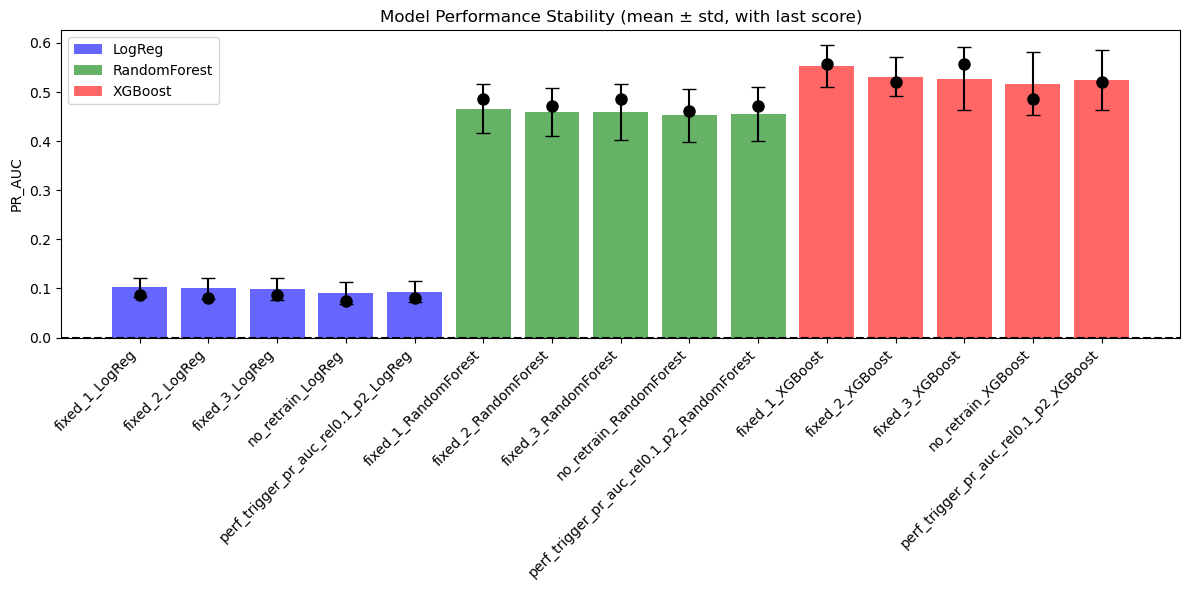

In [64]:
stability_df = stability_summary(all_scores, metric="pr_auc")

colors = {"LogReg": "blue", "RandomForest": "green", "XGBoost": "red"}
metric = "pr_auc"

fig, ax = plt.subplots(figsize=(12,6))

# Plot mean ± std bars
for model_name in stability_df["model"].unique():
    data = stability_df[stability_df["model"] == model_name]
    ax.bar(
        x=data["strategy"] + "_" + model_name,
        height=data["mean"],
        yerr=data["std"],
        capsize=5,
        color=colors.get(model_name, "gray"),
        alpha=0.6,
        label=model_name
    )

# Overlay degradation as a marker (circle)
for idx, row in stability_df.iterrows():
    ax.plot(
        row["strategy"] + "_" + row["model"],
        row["last_score"],
        marker="o",
        color="black",
        markersize=8
    )

ax.set_ylabel(f"{metric.upper()}")
ax.set_title(f"Model Performance Stability (mean ± std, with last score)")
ax.axhline(0, color='black', linestyle='--')
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### Temporal Performance Comparison

The following plots show how model performance changes over time under different retraining strategies.  
These visualizations are useful for identifying:

- the rate of performance degradation
- the effect of retraining on recovery
- differences in temporal stability between models

In [65]:
def plot_metric_over_time(scores_df, metric="pr_auc"):
    plt.figure(figsize=(10, 6))

    for (strategy, model), group in scores_df.groupby(["strategy", "model"]):
        group = group.sort_values("test_window")
        plt.plot(
            group["test_window"],
            group[metric],
            marker="o",
            label=f"{model} - {strategy}"
        )

    plt.xlabel("Test Window")
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} over Time")
    plt.legend()
    plt.grid(True)
    plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.35),
           ncol=3,
           fontsize=9)

    plt.subplots_adjust(top=0.65)
    plt.show()

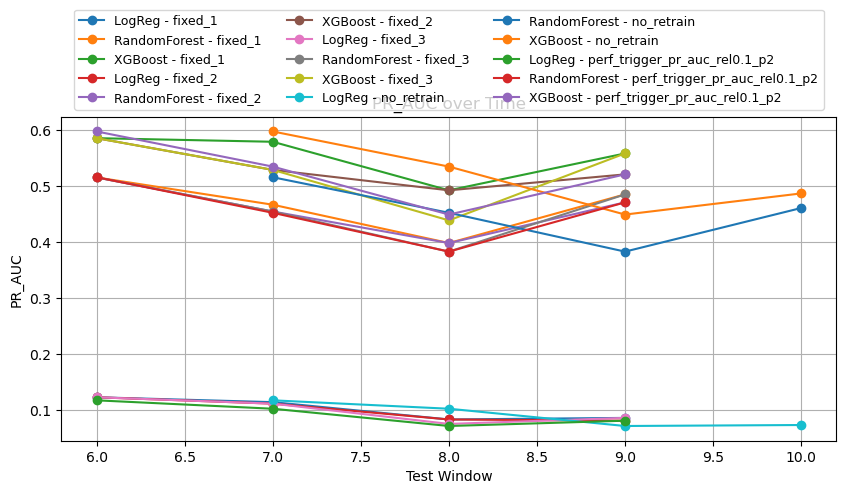

In [66]:
plot_metric_over_time(all_scores, metric="pr_auc")


##### Focused Comparison of the Top Two Models

To improve visual clarity, the following plots focus on the two strongest-performing models.  
This makes it easier to observe differences in temporal stability, degradation patterns, and retraining effects without overcrowding the figure.

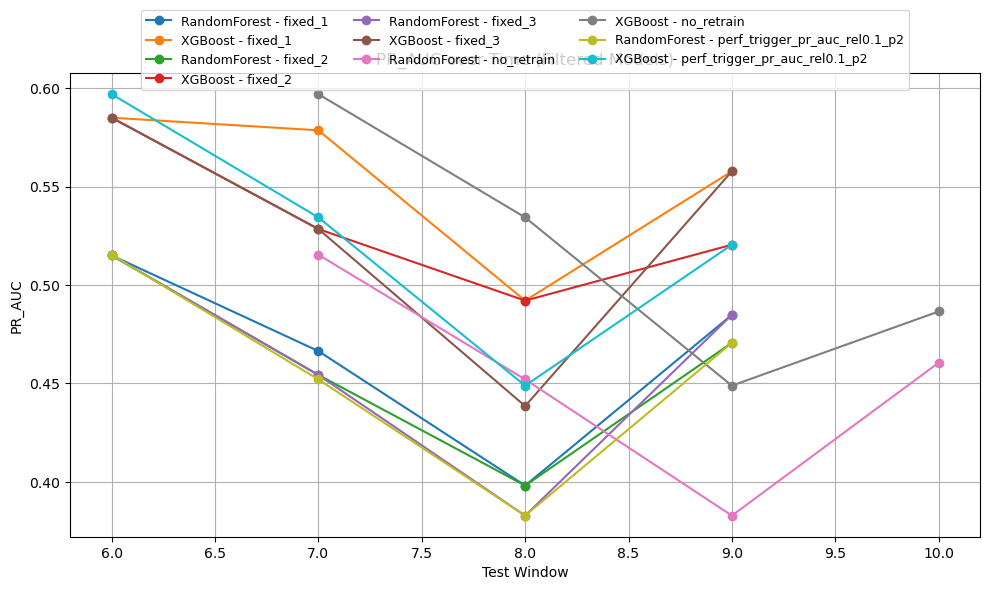

In [67]:
def plot_filtered_metric_over_time(scores_df, metric="pr_auc", models=["XGBoost", "RandomForest"]):
    plt.figure(figsize=(10, 6))
    
    filtered = scores_df[scores_df["model"].isin(models)]
    
    for (strategy, model), group in filtered.groupby(["strategy", "model"]):
        group = group.sort_values("test_window")
        plt.plot(
            group["test_window"],
            group[metric],
            marker="o",
            label=f"{model} - {strategy}"
        )
    
    plt.xlabel("Test Window")
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} over Time (Filtered Models)")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, fontsize=9)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example call:
plot_filtered_metric_over_time(all_scores, metric="pr_auc")

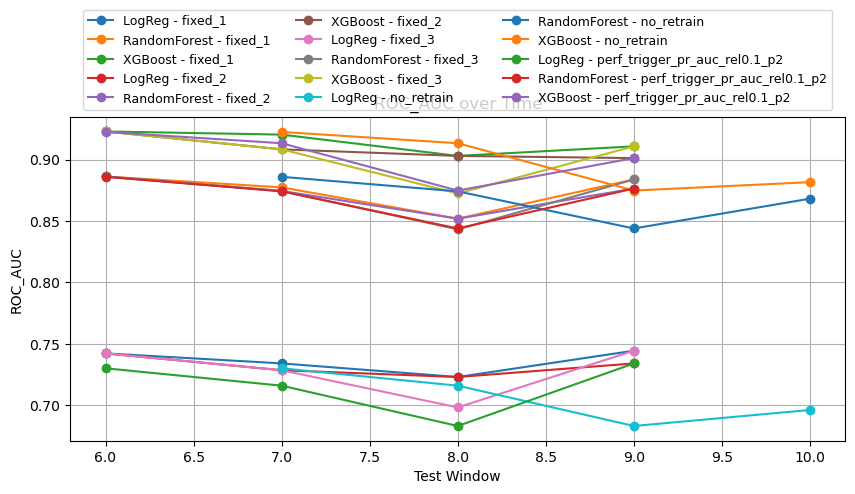

In [68]:
plot_metric_over_time(all_scores, metric="roc_auc")

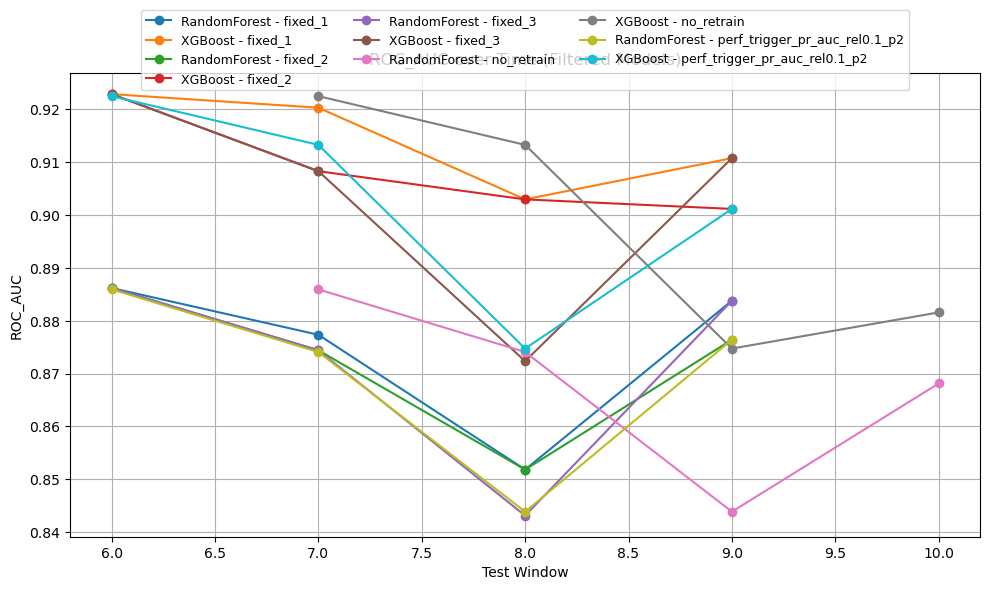

In [69]:
def plot_filtered_roc_auc_over_time(scores_df, models=["XGBoost", "RandomForest"]):
    plt.figure(figsize=(10, 6))
    
    filtered = scores_df[scores_df["model"].isin(models)]
    
    for (strategy, model), group in filtered.groupby(["strategy", "model"]):
        group = group.sort_values("test_window")
        plt.plot(
            group["test_window"],
            group["roc_auc"],
            marker="o",
            label=f"{model} - {strategy}"
        )
    
    plt.xlabel("Test Window")
    plt.ylabel("ROC_AUC")
    plt.title("ROC_AUC over Time (Filtered Models)")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, fontsize=9)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example call:
plot_filtered_roc_auc_over_time(all_scores, models=["XGBoost", "RandomForest"])

### Retraining Events in the Adaptive Strategy

The table below shows the specific time windows where adaptive retraining was triggered.  
This helps verify whether the trigger mechanism responds to meaningful degradation and whether retraining frequency remains reasonable across models.

In [70]:
perf_scores[perf_scores["retrained"] == True]

,strategy,model,test_window,roc_auc,pr_auc,trigger_metric,reference_score,threshold_score,degradation_ratio,bad_count,retrained
18,perf_trigger_pr_auc_rel0.1_p2,RandomForest,8,0.843852,0.382838,0.382838,0.382838,0.463885,0.257242,0,True
14,perf_trigger_pr_auc_rel0.1_p2,LogReg,8,0.682889,0.071986,0.071986,0.071986,0.105973,0.388642,0,True
22,perf_trigger_pr_auc_rel0.1_p2,XGBoost,8,0.874737,0.448896,0.448896,0.448896,0.537358,0.248162,0,True


### Degradation Summary

This section summarizes the extent to which model performance declines over time under each retraining strategy.  
It supports the analysis of temporal robustness by showing whether a strategy is able to preserve performance as the data distribution evolves.

In [71]:
def degradation_summary(scores_df, metric="pr_auc"):
    rows = []

    for (strategy, model), g in scores_df.groupby(["strategy", "model"]):
        g = g.sort_values("test_window")
        first = g.iloc[0][metric]
        last = g.iloc[-1][metric]
        pct_drop = ((first - last) / first * 100) if first != 0 else np.nan

        rows.append({
            "strategy": strategy,
            "model": model,
            "first_window": first,
            "last_window": last,
            "absolute_drop": first - last,
            "percent_drop": pct_drop
        })

    return pd.DataFrame(rows).sort_values(["strategy", "percent_drop"], ascending=[True, False])

In [72]:
degradation_summary(all_scores, metric="pr_auc")

,strategy,model,first_window,last_window,absolute_drop,percent_drop
0,fixed_1,LogReg,0.123184,0.086417,0.036767,29.847370
1,fixed_1,RandomForest,0.515100,0.484877,0.030223,5.867484
2,fixed_1,XGBoost,0.585088,0.557849,0.027240,4.655688
3,fixed_2,LogReg,0.123184,0.081444,0.041740,33.884010
5,fixed_2,XGBoost,0.585088,0.520532,0.064556,11.033595
4,fixed_2,RandomForest,0.515100,0.470663,0.044437,8.626856
6,fixed_3,LogReg,0.123184,0.086417,0.036767,29.847370
7,fixed_3,RandomForest,0.515100,0.484877,0.030223,5.867484
8,fixed_3,XGBoost,0.585088,0.557849,0.027240,4.655688
9,no_retrain,LogReg,0.117747,0.073726,0.044021,37.385994
